# Analyse Exploratoire

## Import des modules

In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from scipy import stats

In [255]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



## Analyse Exploratoire

### Visualisation du dataset

In [256]:
building_consumption = pd.read_csv('./2016_Building_Energy_Benchmarking.csv')

In [257]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [258]:
building_consumption.shape

(3376, 46)

### Consignes

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Quelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

### Suppression des données qui ne concerne pas le projet

In [259]:
# REVOIR SI ON ENLEVE OU NON LES 'NON COMPLIANT DATAS'
#building_consumption['ComplianceStatus'].unique()

In [260]:
building_dic = {'NonResidential': 'NonResidential',
                'Nonresidential COS': 'NonResidential',
                'Multifamily MR (5-9)': 'Residential',
                'SPS-District K-12': 'School',
                'Campus': 'Campus',
                'Multifamily LR (1-4)': 'Residential',
                'Multifamily HR (10+)': 'Residential',
                'Nonresidential WA': 'NonResidential'}

building_consumption['BuildingType']= building_consumption['BuildingType'].map(building_dic)


NR_building_consumption = building_consumption[building_consumption['BuildingType'] !='Residential'].copy()

building_consumption.shape


(3376, 46)

### Traitement outliers par quartile

#### number of floors

<Axes: xlabel='NumberofFloors'>

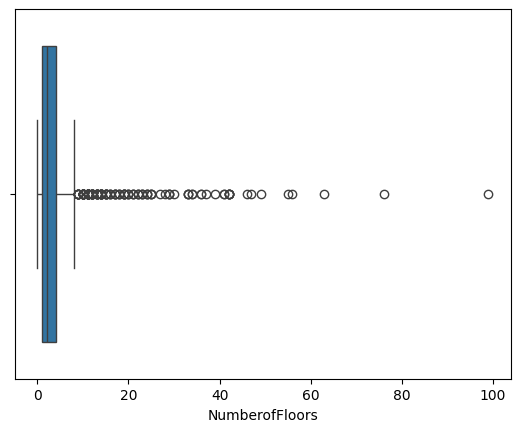

In [261]:
sns.boxplot(x=NR_building_consumption['NumberofFloors'])

<Axes: xlabel='NumberofFloors'>

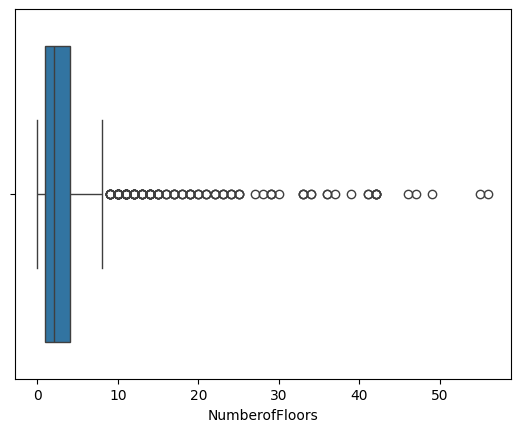

In [262]:
NR_building_consumption.drop(index = NR_building_consumption[NR_building_consumption['NumberofFloors']>60].index,inplace=True)
sns.boxplot(x=NR_building_consumption['NumberofFloors'])

#### GHGEmissionsIntensity

<Axes: xlabel='GHGEmissionsIntensity'>

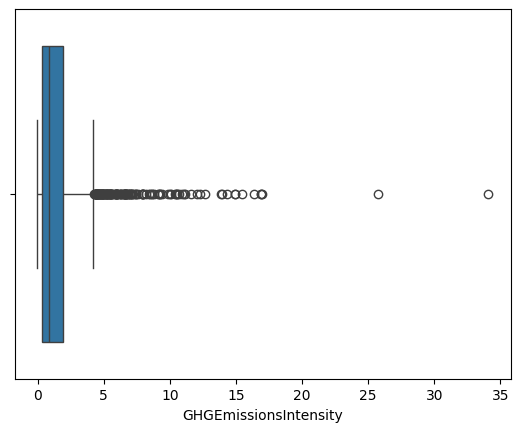

In [263]:
sns.boxplot(x=NR_building_consumption['GHGEmissionsIntensity'])

<Axes: xlabel='GHGEmissionsIntensity'>

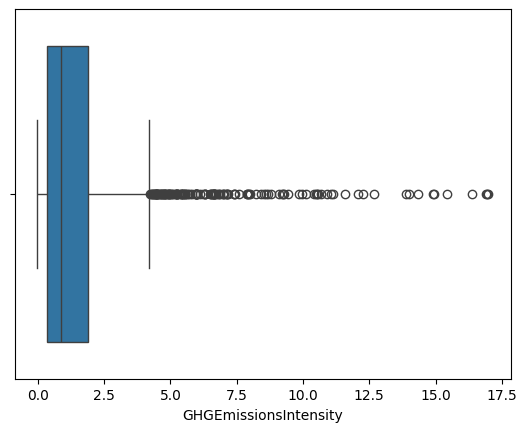

In [264]:
NR_building_consumption.drop(index = NR_building_consumption[NR_building_consumption['GHGEmissionsIntensity']>20].index,inplace=True)
sns.boxplot(x=NR_building_consumption['GHGEmissionsIntensity'])

#### TotalGHGEmissions

<Axes: xlabel='TotalGHGEmissions'>

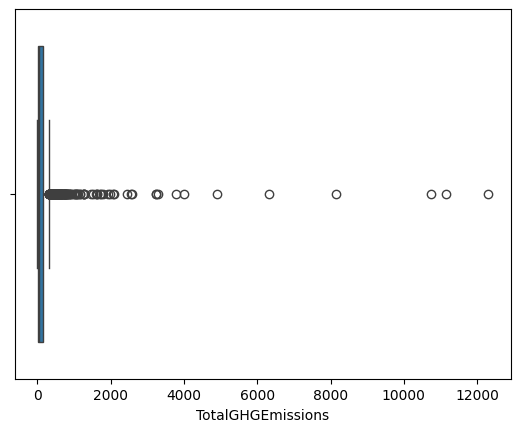

In [265]:
sns.boxplot(x=NR_building_consumption['TotalGHGEmissions'])

<Axes: xlabel='TotalGHGEmissions'>

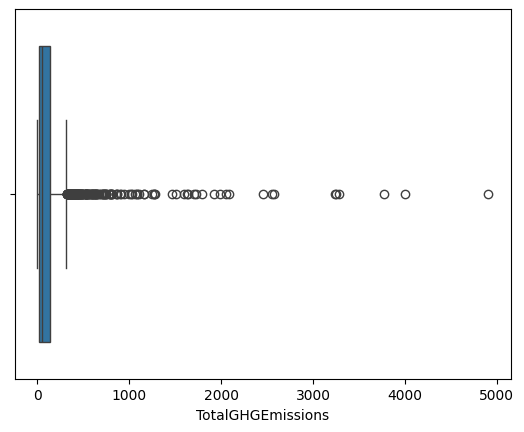

In [266]:
NR_building_consumption.drop(index = NR_building_consumption[NR_building_consumption['TotalGHGEmissions']>6000].index,inplace=True)
sns.boxplot(x=NR_building_consumption['TotalGHGEmissions'])

#### PropertyGFABuilding(s)

<Axes: xlabel='PropertyGFABuilding(s)'>

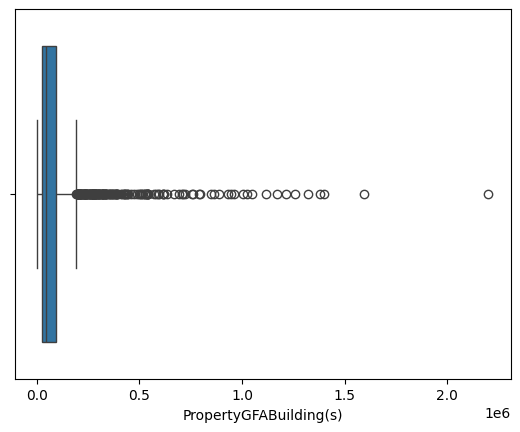

In [267]:
sns.boxplot(x=NR_building_consumption['PropertyGFABuilding(s)'])

<Axes: xlabel='PropertyGFABuilding(s)'>

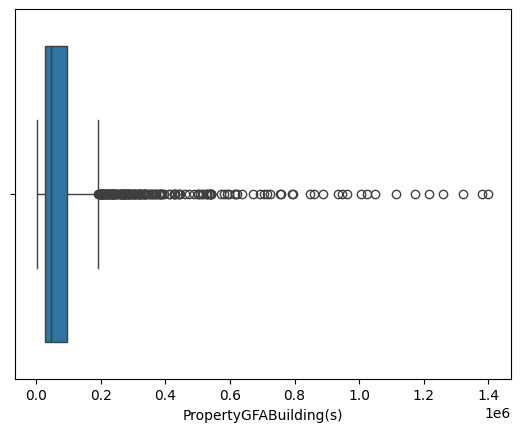

In [268]:
NR_building_consumption.drop(index = NR_building_consumption[NR_building_consumption['PropertyGFABuilding(s)']>1500000].index,inplace=True)
sns.boxplot(x=NR_building_consumption['PropertyGFABuilding(s)'])

In [269]:
NR_building_WO_outliers_consumption = NR_building_consumption
NR_building_WO_outliers_consumption.shape

(1656, 46)

In [270]:
NR_building_WO_outliers_consumption= NR_building_WO_outliers_consumption[NR_building_WO_outliers_consumption['ComplianceStatus'] == 'Compliant']

In [271]:
NR_building_WO_outliers_consumption['NumberofBuildings'].fillna(value=1, inplace=True)
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['NumberofBuildings']==0,'NumberofBuildings'] = 1
NR_building_WO_outliers_consumption['NumberofBuildings'].value_counts()

C:\Users\Fabien\AppData\Local\Temp\ipykernel_24672\4092874030.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  NR_building_WO_outliers_consumption['NumberofBuildings'].fillna(value=1, inplace=True)
C:\Users\Fabien\AppData\Local\Temp\ipykernel_24672\4092874030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consum

NumberofBuildings
1.0     1488
2.0       14
3.0       12
5.0        7
4.0        4
6.0        3
8.0        2
14.0       2
27.0       1
11.0       1
23.0       1
10.0       1
Name: count, dtype: int64

In [272]:
# def quantile_outliers(column):
#     q1 = column.quantile(0.25)
#     q3 = column.quantile(0.75)

#     iqr = q3 - q1

#     low_limite = q1 - 1.5 *iqr
#     high_limite = q3 + 1.5 * iqr
#     return [low_limite,high_limite]

In [273]:
outlier_columns = ['GHGEmissionsIntensity','TotalGHGEmissions','PropertyGFABuilding(s)',]
# TempQuartOutliers = NR_building_consumption
# for column in outlier_columns:
#     limite_basse, limite_haute = quantile_outliers(TempQuartOutliers[column])
#     TempQuartOutliers = TempQuartOutliers[(TempQuartOutliers[column]>limite_basse) & (TempQuartOutliers[column]<limite_haute)]
#     print(TempQuartOutliers.shape)

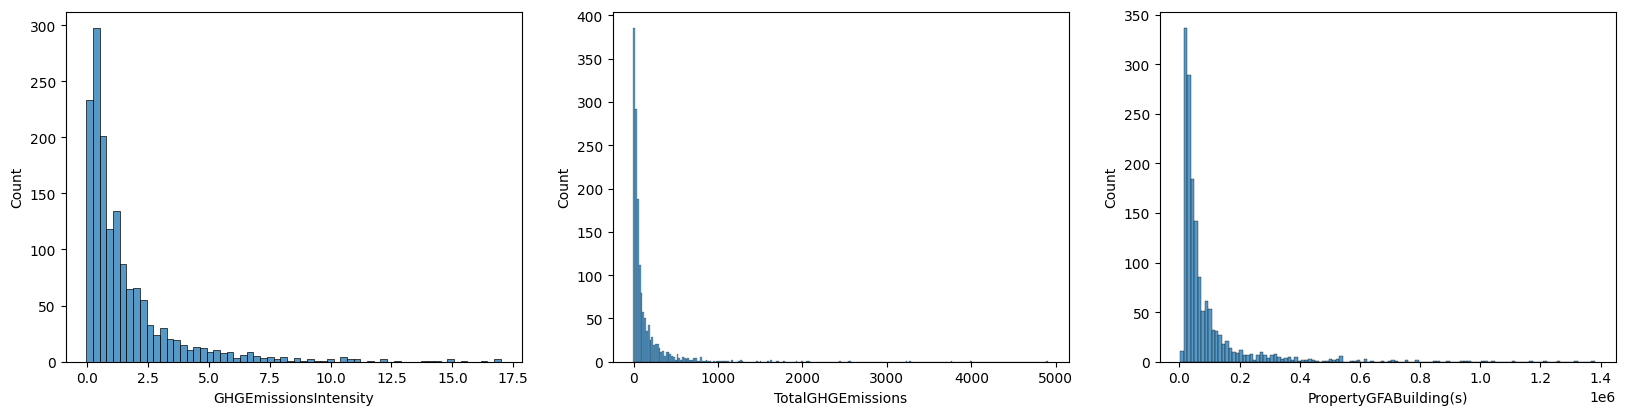

In [274]:
plt.figure(figsize=(20,10))
for i,column in enumerate(outlier_columns):
    plt.subplot(int(len(outlier_columns)/3)+1,3,i+1)
    sns.histplot(data=NR_building_WO_outliers_consumption[column])


In [275]:
NR_building_WO_outliers_consumption.drop(index=NR_building_WO_outliers_consumption[NR_building_WO_outliers_consumption['SiteEUI(kBtu/sf)'].isna()].index,inplace=True)
NR_building_WO_outliers_consumption.isna().sum()

C:\Users\Fabien\AppData\Local\Temp\ipykernel_24672\842063396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption.drop(index=NR_building_WO_outliers_consumption[NR_building_WO_outliers_consumption['SiteEUI(kBtu/sf)'].isna()].index,inplace=True)


OSEBuildingID                         0
DataYear                              0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
Address                               0
City                                  0
State                                 0
ZipCode                              13
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     0
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             0
LargestPropertyUseType                4
LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseType        702
SecondLargestPropertyUseTypeGFA     702


<Axes: xlabel='SiteEnergyUse(kBtu)', ylabel='SiteEnergyUseWN(kBtu)'>

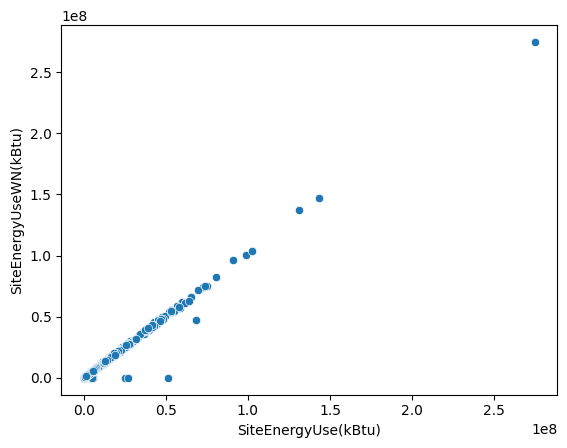

In [276]:
sns.scatterplot(data=NR_building_WO_outliers_consumption ,x= 'SiteEnergyUse(kBtu)', y='SiteEnergyUseWN(kBtu)')

### Suppression des colonnes inutiles

In [277]:
columns_to_drop = ['TaxParcelIdentificationNumber','ZipCode',
                   'Address','PropertyName','DataYear','City','State','Outlier',
                    'ComplianceStatus' , 'Comments' , 'NaturalGas(therms)' ,'DefaultData',
                    'Electricity(kWh)' ,'SourceEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)','YearsENERGYSTARCertified']

NR_building_WO_outliers_consumption.drop(columns_to_drop, axis=1, inplace=True)
NR_building_WO_outliers_consumption.shape

C:\Users\Fabien\AppData\Local\Temp\ipykernel_24672\1928625636.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption.drop(columns_to_drop, axis=1, inplace=True)


(1536, 30)

- 'TaxParcelIdentificationNumber','ZipCode','Address','PropertyName','DataYear','City','State','Outlier', 'ComplianceStatus' , 'Comments' ,'DefaultData' = valeur constante ou ne servent à rien  
- 'NaturalGas(therms)' , 'Electricity(kWh)' = Doublon avec la valeur en kBtu  
- 'SourceEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)' = doublon avec les siteEnergyuse  
- 'YearsENERGYSTARCertified' = trop de Na  


### Suppression de la valeur NA dans site EUIW

In [278]:
NR_building_WO_outliers_consumption= NR_building_WO_outliers_consumption[NR_building_WO_outliers_consumption['SiteEUIWN(kBtu/sf)'].notna()]
NR_building_WO_outliers_consumption.shape

(1535, 30)

**Décision :** Variable cible = **TotalGHGEmissions**

### Prouver la relation entre les energies et le CO²

(0.0, 7000000.0)

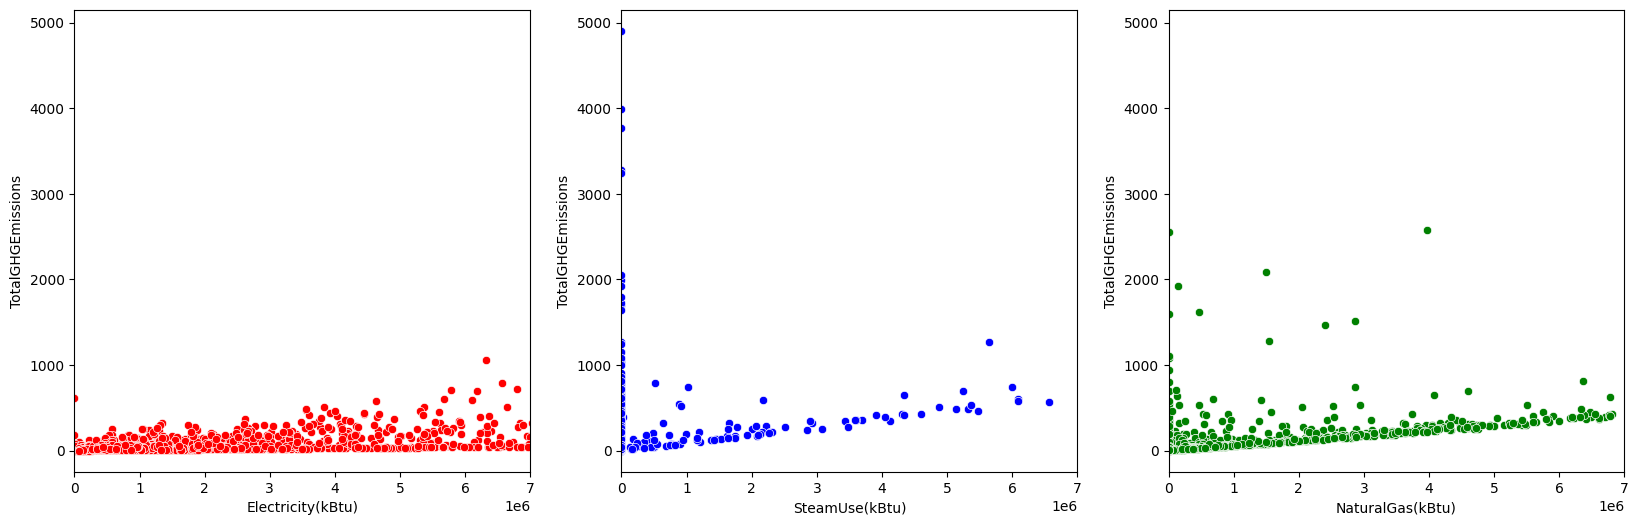

In [279]:
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
sns.scatterplot(data=NR_building_WO_outliers_consumption, x='Electricity(kBtu)', y='TotalGHGEmissions', c='red')
plt.xlim(0,7000000)
plt.subplot(1,3,2)
sns.scatterplot(data=NR_building_WO_outliers_consumption, x='SteamUse(kBtu)', y='TotalGHGEmissions', c ='blue')
plt.xlim(0,7000000)
plt.subplot(1,3,3)
sns.scatterplot(data=NR_building_WO_outliers_consumption, x='NaturalGas(kBtu)', y='TotalGHGEmissions', c ='green')
plt.xlim(0,7000000)

**Conclusion :** Il y a une forte corrélation entre la consommation des énergies et le CO²  
On peut aussi deviner que la vapeur emet plus que le gaz qui lui même emet plus que l'electricité 

### Prouver la relation entre type de propriété et ENERGYSTAR

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'Hotel'),
  Text(1, 0, 'Other'),
  Text(2, 0, 'Mixed Use Property'),
  Text(3, 0, 'University'),
  Text(4, 0, 'Small- and Mid-Sized Office'),
  Text(5, 0, 'Self-Storage Facility'),
  Text(6, 0, 'Warehouse'),
  Text(7, 0, 'K-12 School'),
  Text(8, 0, 'Large Office'),
  Text(9, 0, 'Senior Care Community'),
  Text(10, 0, 'Medical Office'),
  Text(11, 0, 'Retail Store'),
  Text(12, 0, 'Hospital'),
  Text(13, 0, 'Residence Hall'),
  Text(14, 0, 'Distribution Center'),
  Text(15, 0, 'Worship Facility'),
  Text(16, 0, 'Supermarket / Grocery Store'),
  Text(17, 0, 'Laboratory'),
  Text(18, 0, 'Refrigerated Warehouse'),
  Text(19, 0, 'Restaurant'),
  Text(20, 0, 'Low-Rise Multifamily')])

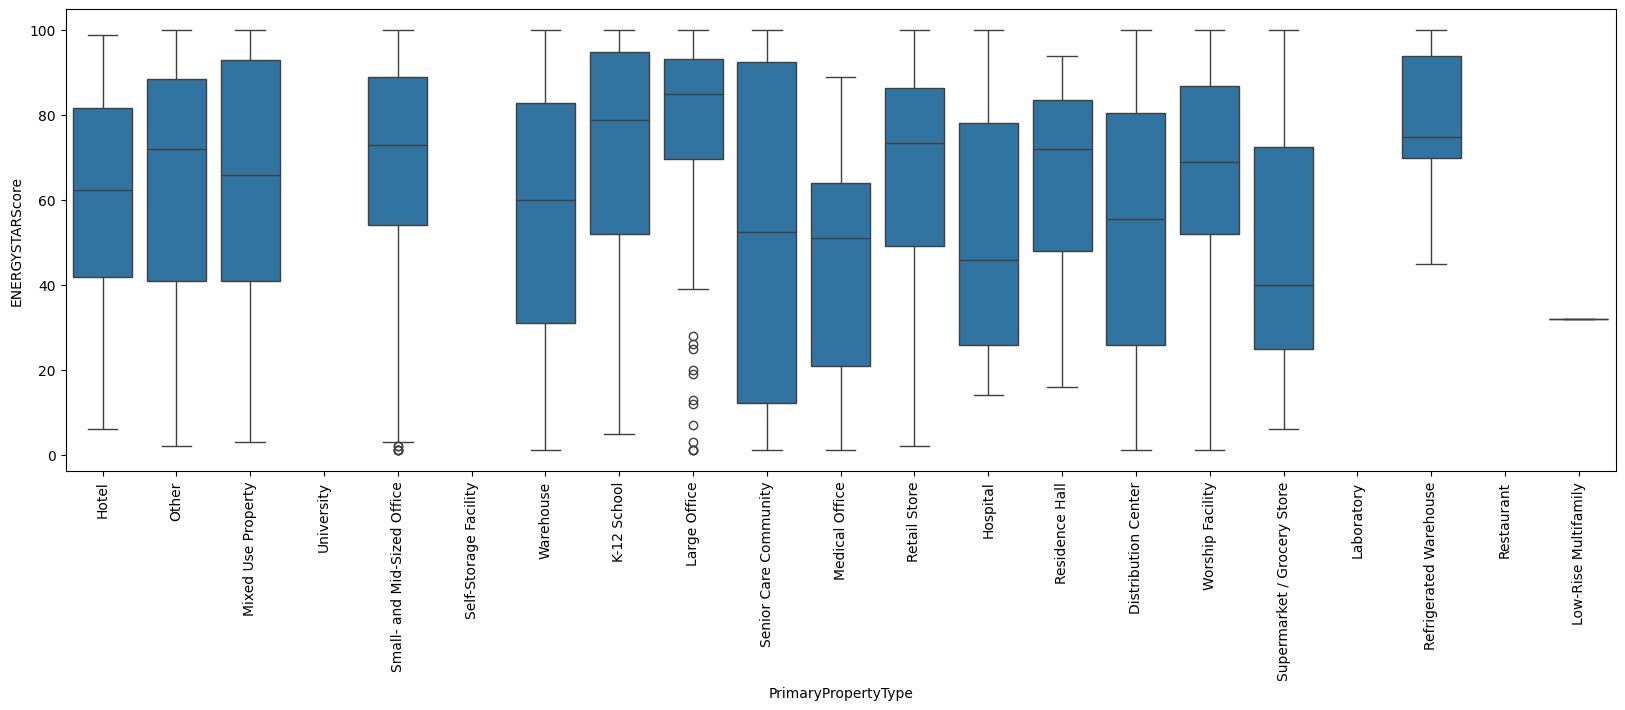

In [280]:
plt.figure(figsize=(20,6))
sns.boxplot(data= NR_building_WO_outliers_consumption, x='PrimaryPropertyType', y='ENERGYSTARScore')
plt.xticks(rotation=90)

### Nettoyage des varaible de 'NEIGHBORHOOD

In [281]:
# ['DOWNTOWN', 'NORTHEAST', 'Central', 'MAGNOLIA / QUEEN ANNE',
#        'BALLARD', 'GREATER DUWAMISH', 'LAKE UNION', 'CENTRAL',
#        'SOUTHWEST', 'DELRIDGE', 'EAST', 'SOUTHEAST', 'NORTHWEST', 'NORTH',
#        'North', 'Delridge', 'Ballard', 'Northwest',
#        'DELRIDGE NEIGHBORHOODS']
NR_building_WO_outliers_consumption['Neighborhood'] = NR_building_WO_outliers_consumption['Neighborhood'].str.upper()
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['Neighborhood']=='DELRIDGE NEIGHBORHOODS','Neighborhood'] = 'DELRIDGE'
NR_building_WO_outliers_consumption['Neighborhood'].unique()

array(['DOWNTOWN', 'NORTHEAST', 'EAST', 'LAKE UNION', 'GREATER DUWAMISH',
       'MAGNOLIA / QUEEN ANNE', 'BALLARD', 'NORTHWEST', 'CENTRAL',
       'SOUTHWEST', 'SOUTHEAST', 'DELRIDGE', 'NORTH'], dtype=object)

### Classification de l'ENERGYSTAR pour combler les NA

(987, 11)
TotalGHGEmissions | skew = 0.00023302846041158533 | kurt = -0.0456947773779639 | Statistique = 0.9991545263794951 | p-value = 0.9436118018099565
SiteEUI(kBtu/sf) | skew = 0.12234416566257678 | kurt = 2.396368883620525 | Statistique = 0.9640484605475512 | p-value = 7.028166518653817e-15
SiteEUIWN(kBtu/sf) | skew = 0.2355740252875607 | kurt = 3.205870148637601 | Statistique = 0.9478337884548131 | p-value = 3.4296525120465085e-18


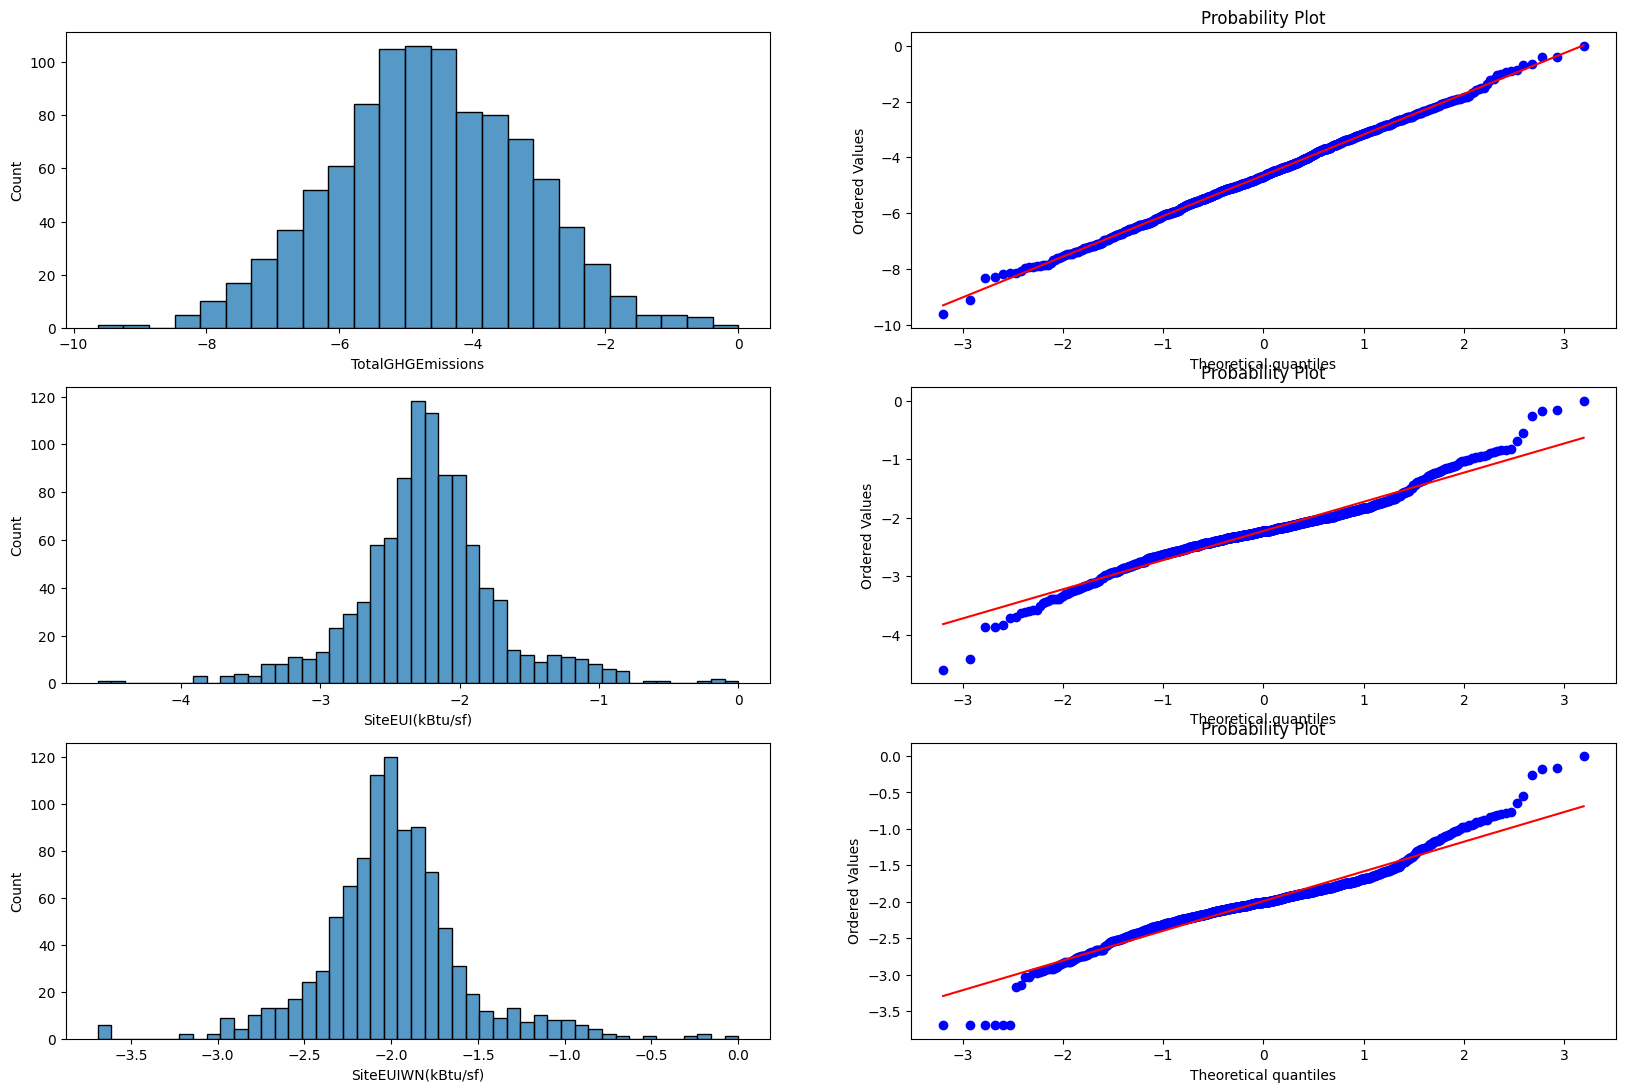

In [282]:
df = NR_building_WO_outliers_consumption

# nrj_outlier_columns = ['SiteEUI(kBtu/sf)','SiteEnergyUse(kBtu)']

# for column in nrj_outlier_columns:
#     limite_basse, limite_haute = quantile_outliers(df[column])
#     df = df[(df[column]>limite_basse) & (df[column]<limite_haute)]
#     print(df.shape)

# Sélection des variables de base
X_nrj = df.loc[df['ENERGYSTARScore'].notna(),
    ['SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
     'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'PrimaryPropertyType', 'YearBuilt',
     'PropertyGFABuilding(s)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions',
     'GHGEmissionsIntensity']]
print(X_nrj.shape)

columns_to_normalize = ['TotalGHGEmissions' , 'SiteEUI(kBtu/sf)' , 'SiteEUIWN(kBtu/sf)'] #,'PropertyGFABuilding(s)'

from sklearn.preprocessing import PowerTransformer
from scipy.stats import shapiro

STDscaler = MinMaxScaler()

for column in X_nrj[columns_to_normalize] :
    X_nrj[column] = STDscaler.fit_transform(X_nrj[[column]])
    X_nrj.loc[X_nrj[column]==0,column] = 0.0001
    


plt.figure(figsize=(20,50))
for i, colonne in enumerate(columns_to_normalize):
    X_nrj[colonne], coef = stats.boxcox(X_nrj[colonne]) #TotalGHGEmissions , SiteEUI(kBtu/sf) , SiteEUIWN(kBtu/sf)

    plt.subplot(X_nrj.shape[1],2,i*2+1)
    sns.histplot(X_nrj, x=colonne)
    plt.subplot(X_nrj.shape[1],2,i*2+2)
    stats.probplot(X_nrj[colonne], plot=plt)

    stat, p = shapiro(X_nrj[colonne])
    print(f'{colonne} | skew = {X_nrj[colonne].skew()} | kurt = {X_nrj[colonne].kurtosis()} | Statistique = {stat} | p-value = {p}')



In [283]:
X_nrj['PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    234
Large Office                   156
Warehouse                      141
Hotel                           72
Retail Store                    72
Worship Facility                62
K-12 School                     49
Distribution Center             40
Supermarket / Grocery Store     39
Medical Office                  37
Mixed Use Property              25
Residence Hall                  19
Senior Care Community           18
Other                           11
Hospital                         6
Refrigerated Warehouse           5
Low-Rise Multifamily             1
Name: count, dtype: int64

In [284]:
y_nrj = df.loc[df['ENERGYSTARScore'].notna(),'ENERGYSTARScore']

# Encodage OneHot de la variable catégorielle
PrimaryPropertyType_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
df_encoded = PrimaryPropertyType_encoder.fit_transform(X_nrj[['PrimaryPropertyType']])
X_nrj = pd.concat([X_nrj.drop('PrimaryPropertyType', axis=1), df_encoded.astype(bool)], axis=1)

#
# Split train/test
X_nrj_train, X_nrj_test, y_nrj_train, y_nrj_test = train_test_split(X_nrj, y_nrj, test_size=0.2, random_state=42)
colonnes_entraînement = X_nrj_train.columns.tolist()

# Normalisation
# MM_scaler = MinMaxScaler()
# X_nrj_train_normalized = MM_scaler.fit_transform(X_nrj_train)
# X_nrj_test_normalized = MM_scaler.transform(X_nrj_test)

# Modèle Gradient Boosting avec paramètres optimisés
params_GB = {
    'learning_rate': 0.05,
    'max_depth': 3,
    'min_samples_leaf': 3,
    'min_samples_split': 2,
    'n_estimators': 200,
    'subsample': 0.6
}
GB_nrj_model = GradientBoostingRegressor(**params_GB, random_state=42)

# Entraînement et évaluation
GB_nrj_model.fit(X_nrj_train, y_nrj_train)
y_nrj_pred = GB_nrj_model.predict(X_nrj_test)

print("MAE :", mean_absolute_error(y_pred=y_nrj_pred, y_true=y_nrj_test))
print("MSE :", mean_squared_error(y_pred=y_nrj_pred, y_true=y_nrj_test))
print("R²  :", r2_score(y_pred=y_nrj_pred, y_true=y_nrj_test))


MAE : 13.87534615439069
MSE : 349.26077947936955
R²  : 0.5509651674261512


#### Application du modèle sur les valeurs NA 

In [285]:
X_nrj_na = NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna(),
    ['SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
     'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'PrimaryPropertyType', 'YearBuilt',
     'PropertyGFABuilding(s)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions',
     'GHGEmissionsIntensity']]



In [286]:
for column in X_nrj_na[columns_to_normalize] :
    X_nrj_na[column] = STDscaler.fit_transform(X_nrj_na[[column]])
    X_nrj_na.loc[X_nrj_na[column]==0,column] = 0.0001

for colonne in columns_to_normalize:
    X_nrj_na[colonne], coef = stats.boxcox(X_nrj_na[colonne]) #TotalGHGEmissions , SiteEUI(kBtu/sf) , SiteEUIWN(kBtu/sf)


df_encoded = PrimaryPropertyType_encoder.transform(X_nrj_na[['PrimaryPropertyType']])
X_nrj_na = pd.concat([X_nrj_na.drop('PrimaryPropertyType', axis=1), df_encoded.astype(bool)], axis=1)
    
y_pred_na = GB_nrj_model.predict(X_nrj_na)

NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna(), 'ENERGYSTARScore'] = y_pred_na
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore']>100, 'ENERGYSTARScore'] = 100

In [287]:
print(df.shape)
NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna().sum()

(1535, 30)


np.int64(0)

In [288]:
# EnergyMean = NR_building_WO_outliers_consumption['ENERGYSTARScore'].dropna().mean()
# print(EnergyMean)
# NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna(),'ENERGYSTARScore'] = EnergyMean

<Axes: xlabel='ENERGYSTARScore', ylabel='Count'>

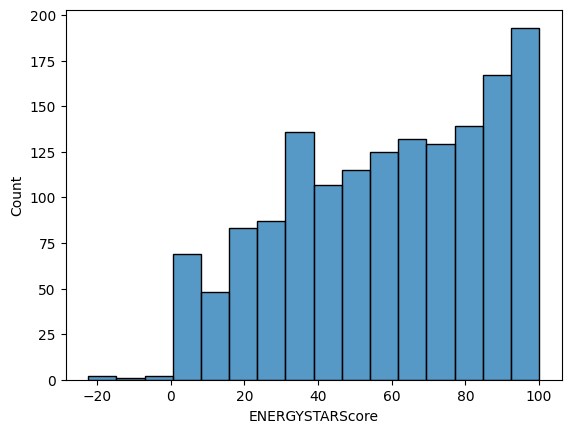

In [289]:
sns.histplot(NR_building_WO_outliers_consumption, x='ENERGYSTARScore')

### Attribution de la moyenne au valeur NA de ENERGYSTARScore

# Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

## Traitement des données contre le dataLeakage

In [290]:
# Création de HasElectricity , HasSteam , HasGas , isMultiUsage, hasParking
NR_building_WO_outliers_consumption['HasElectricity'] = NR_building_WO_outliers_consumption['Electricity(kBtu)'] > 0
NR_building_WO_outliers_consumption['HasSteam'] = NR_building_WO_outliers_consumption['SteamUse(kBtu)'] > 0
NR_building_WO_outliers_consumption['HasGas'] = NR_building_WO_outliers_consumption['NaturalGas(kBtu)'] > 0
NR_building_WO_outliers_consumption['HasParking'] = NR_building_WO_outliers_consumption['PropertyGFAParking'] > 0
NR_building_WO_outliers_consumption['ElecRatio'] = NR_building_WO_outliers_consumption['Electricity(kBtu)'] /NR_building_WO_outliers_consumption['SiteEUI(kBtu/sf)']
NR_building_WO_outliers_consumption['SteamRatio'] = NR_building_WO_outliers_consumption['SteamUse(kBtu)'] /NR_building_WO_outliers_consumption['SiteEUI(kBtu/sf)']
NR_building_WO_outliers_consumption['NaturalGasRatio'] = NR_building_WO_outliers_consumption['NaturalGas(kBtu)'] /NR_building_WO_outliers_consumption['SiteEUI(kBtu/sf)']

In [291]:
dataLeakage_cols =['SiteEUI(kBtu/sf)','SiteEUIWN(kBtu/sf)','SiteEnergyUse(kBtu)',
                'SiteEnergyUseWN(kBtu)','SteamUse(kBtu)','Electricity(kBtu)','NaturalGas(kBtu)']
NR_building_WO_outliers_consumption.drop(dataLeakage_cols,axis=1,inplace=True)
NR_building_WO_outliers_consumption.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,ENERGYSTARScore,TotalGHGEmissions,GHGEmissionsIntensity,HasElectricity,HasSteam,HasGas,HasParking,ElecRatio,SteamRatio,NaturalGasRatio
0,1,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,...,60.0,249.98,2.83,True,True,True,False,48298.985891,24527.320377,15623.660314
1,2,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,...,61.0,295.86,2.86,True,False,True,True,34207.287929,0.000000,54273.015132
2,3,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,...,43.0,2089.28,2.19,True,True,True,True,515902.750000,224651.604167,15560.416667
3,5,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,...,56.0,286.43,4.67,True,True,True,False,24990.288109,19985.976426,16346.687268
4,8,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,...,75.0,505.01,2.88,True,False,True,True,46764.868075,0.000000,76689.875978


# Préparation des features pour la modélisation

A réaliser :
* ~~Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.~~
* ~~Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.~~
* ~~Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn~~
* ~~Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).~~
* ~~Séparez votre jeu de données en un Pandas DataFrame X (ensemble de features) et Pandas Series y (votre target).~~
* ~~Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder~~

## Distribution de la valeur cible **TotalGHGEmissions**

<Axes: xlabel='TotalGHGEmissions', ylabel='Count'>

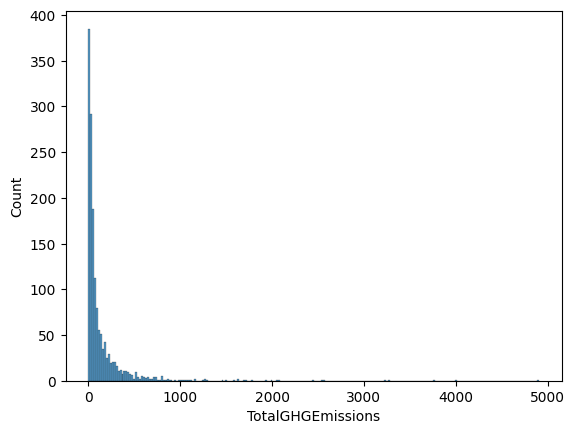

In [292]:
sns.histplot(data= NR_building_WO_outliers_consumption['TotalGHGEmissions'])


## Analyse par matrice de correlation et suppression des variables redondantes (QUANTITATIF)

### Heatmap globale

<Axes: >

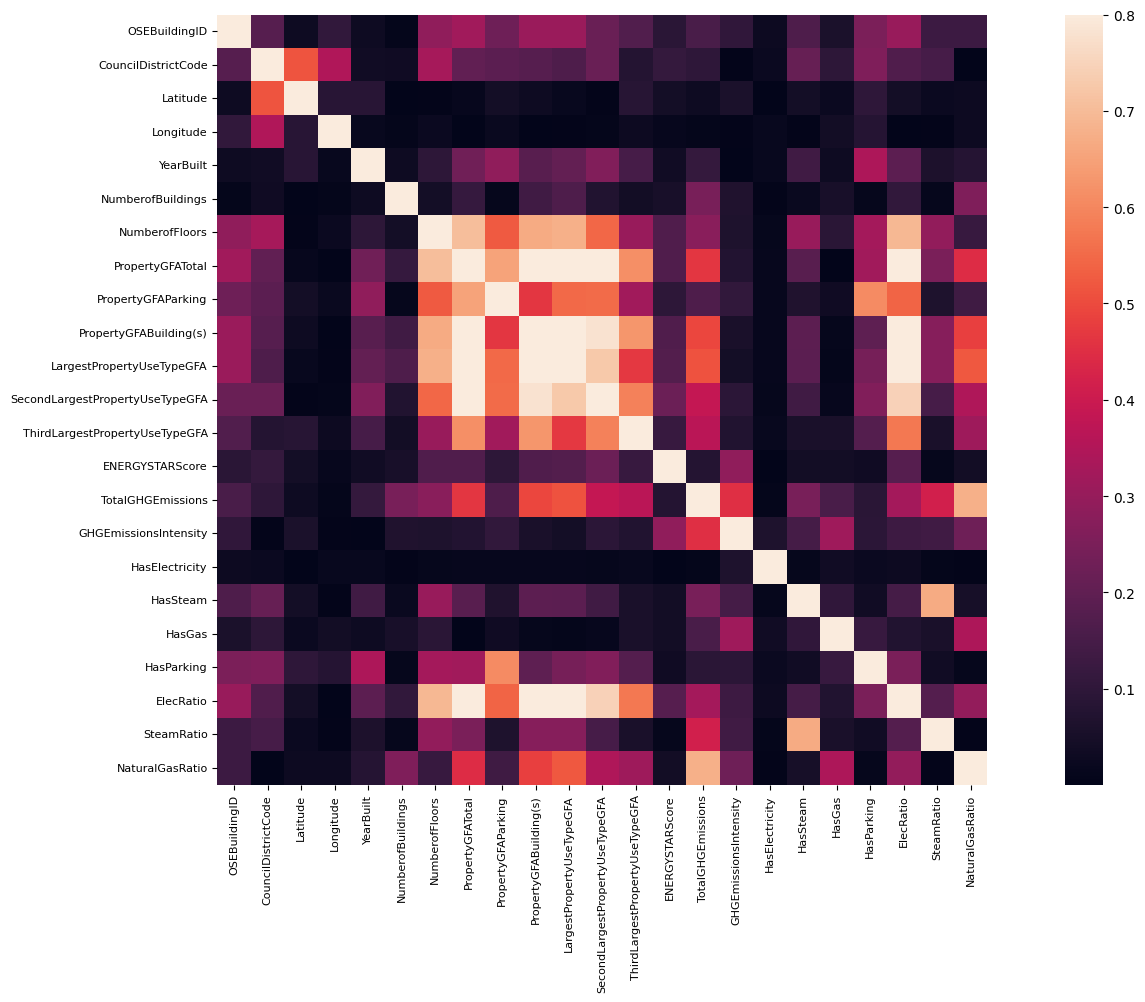

In [293]:
features_numerique = NR_building_WO_outliers_consumption.columns[(NR_building_WO_outliers_consumption.dtypes != object)]
corr_mat  = NR_building_WO_outliers_consumption[features_numerique].corr().abs()
plt.figure(figsize=(20,10))
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
sns.heatmap(corr_mat,annot=False,vmax=0.8,square=True)

In [294]:
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['LargestPropertyUseTypeGFA'].isna(),'LargestPropertyUseTypeGFA'] = 0
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['SecondLargestPropertyUseTypeGFA'].isna(),'SecondLargestPropertyUseTypeGFA'] = 0
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ThirdLargestPropertyUseTypeGFA'].isna(),'ThirdLargestPropertyUseTypeGFA'] = 0

### Heatmap des 10 variables les plus corrélées à ma variable cible

Index(['TotalGHGEmissions', 'NaturalGasRatio', 'LargestPropertyUseTypeGFA',
       'PropertyGFABuilding(s)', 'PropertyGFATotal', 'GHGEmissionsIntensity',
       'SteamRatio', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ElecRatio'],
      dtype='object')


<Axes: >

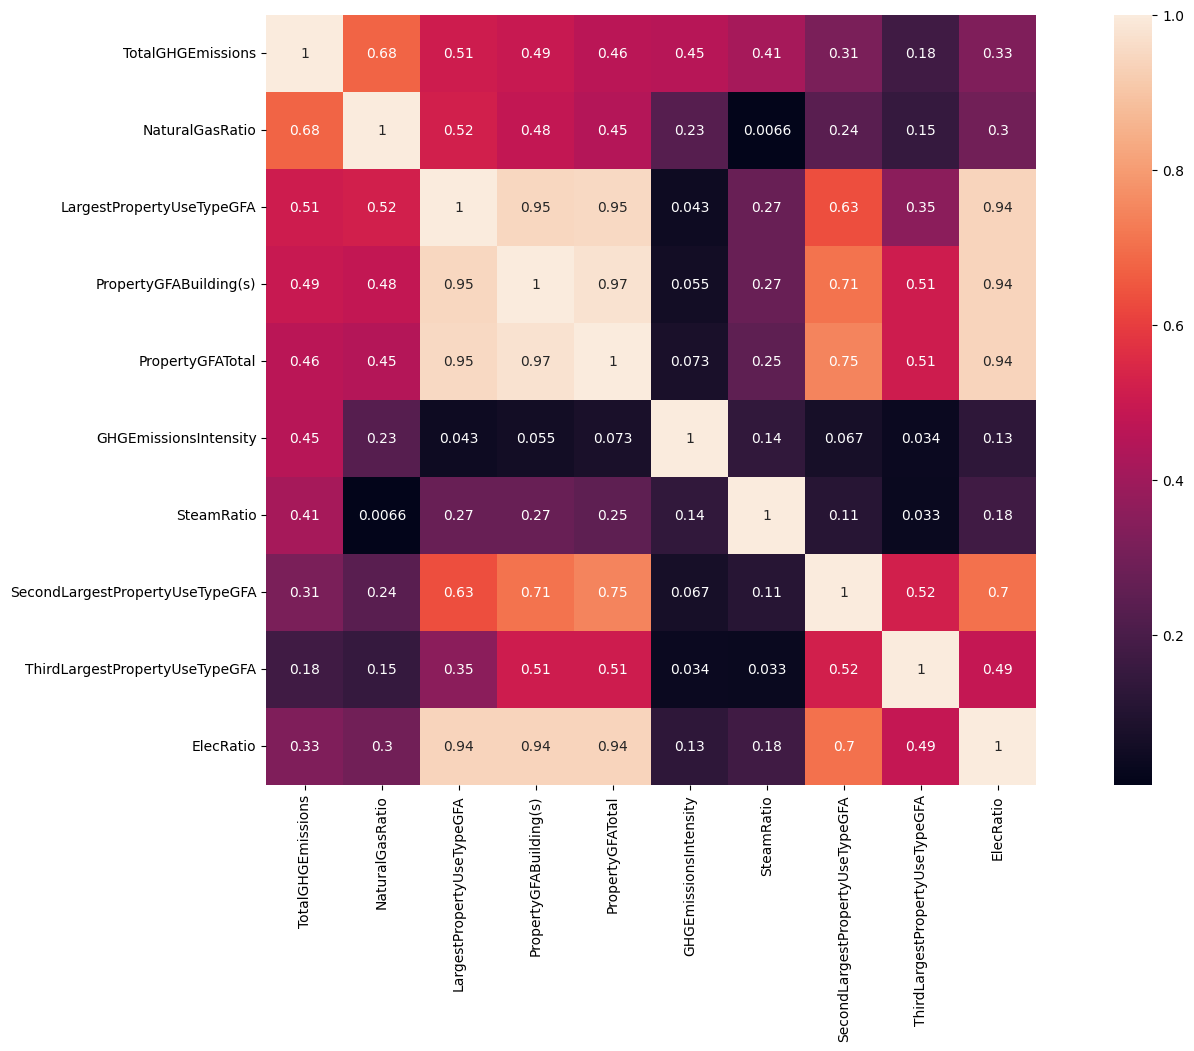

In [295]:
top_cols = corr_mat.nlargest(10,['TotalGHGEmissions'])['TotalGHGEmissions'].index
print(top_cols)
top_cols_corr = NR_building_WO_outliers_consumption[top_cols].corr().abs()
plt.figure(figsize=(20,10))
sns.heatmap(data = top_cols_corr,annot=True, square=True)


In [296]:
redundante_cols = ['GHGEmissionsIntensity','ListOfAllPropertyUseTypes',
                   'PrimaryPropertyType','CouncilDistrictCode','OSEBuildingID'
                   ]#'PropertyGFATotal','PropertyGFAParking','PropertyGFABuilding(s)'

NR_building_WO_outliers_consumption.drop(redundante_cols, axis=1,inplace= True)
NR_building_WO_outliers_consumption.columns

Index(['BuildingType', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'ENERGYSTARScore', 'TotalGHGEmissions', 'HasElectricity', 'HasSteam',
       'HasGas', 'HasParking', 'ElecRatio', 'SteamRatio', 'NaturalGasRatio'],
      dtype='object')

## Analyse par matrice de contingence (QUALITATIF)

<Axes: xlabel='BuildingType', ylabel='LargestPropertyUseType'>

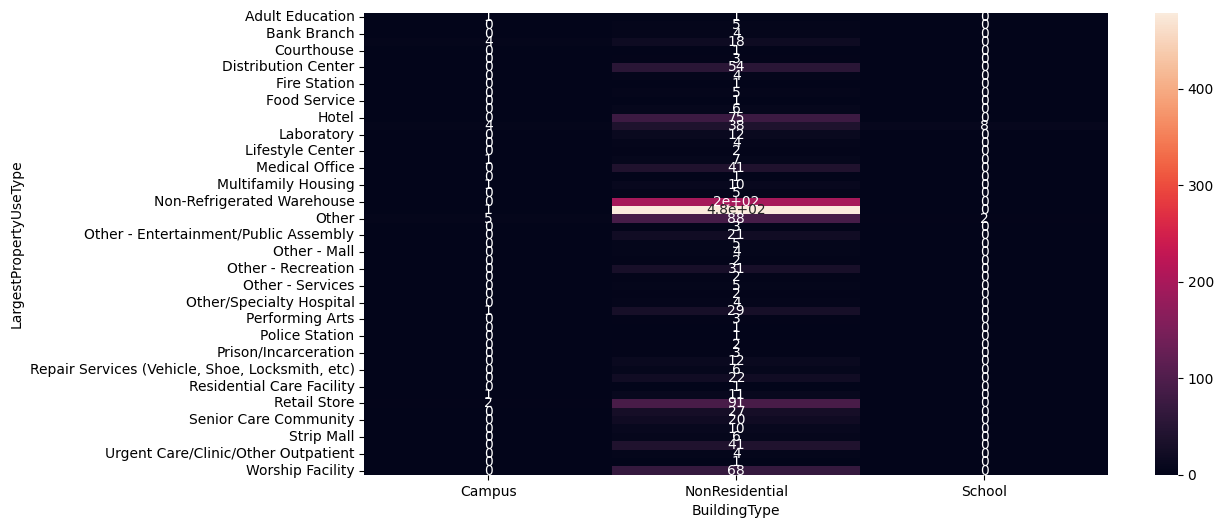

In [297]:
matrice_contingence = pd.crosstab(NR_building_WO_outliers_consumption['LargestPropertyUseType'],NR_building_WO_outliers_consumption['BuildingType'])
plt.figure(figsize=(12,6))
sns.heatmap(matrice_contingence,annot=True)

**Conclusion :** Il semblerait que la diversité des BuildingType ne soit pas necessaire. Nous garderons uniquement les primarypropertyType

In [298]:
NR_building_WO_outliers_consumption.drop(['BuildingType'], axis=1, inplace=True)

In [299]:
NR_building_WO_outliers_consumption.columns

Index(['Neighborhood', 'Latitude', 'Longitude', 'YearBuilt',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'ENERGYSTARScore', 'TotalGHGEmissions', 'HasElectricity', 'HasSteam',
       'HasGas', 'HasParking', 'ElecRatio', 'SteamRatio', 'NaturalGasRatio'],
      dtype='object')

## Encodage des variable qualitatives

### Encodage de buildingType

In [300]:
# OHE_BuildingType = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')
# encoded_df =OHE_BuildingType.fit_transform(NR_building_WO_outliers_consumption[['BuildingType']])
# NR_building_WO_outliers_consumption = pd.concat([NR_building_WO_outliers_consumption,encoded_df.astype(bool)],axis=1).drop('BuildingType', axis=1)

### Encodage de LargestPropertyUseType,2,3

In [301]:
LE_LargestPropertyUseType = LabelEncoder()
NR_building_WO_outliers_consumption['LargestPropertyUseType'] = LE_LargestPropertyUseType.fit_transform(NR_building_WO_outliers_consumption['LargestPropertyUseType'])


In [302]:
LE_SecondLargestPropertyUseType = LabelEncoder()
NR_building_WO_outliers_consumption['SecondLargestPropertyUseType'] = LE_SecondLargestPropertyUseType.fit_transform(NR_building_WO_outliers_consumption['SecondLargestPropertyUseType'])

In [303]:
LE_ThirdLargestPropertyUseType = LabelEncoder()
NR_building_WO_outliers_consumption['ThirdLargestPropertyUseType'] = LE_ThirdLargestPropertyUseType.fit_transform(NR_building_WO_outliers_consumption['ThirdLargestPropertyUseType'])

### Encodage de Neighborhood

In [304]:
OHE_Neighborhood = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
encoded_df = OHE_Neighborhood.fit_transform(NR_building_WO_outliers_consumption[['Neighborhood']])
NR_building_WO_outliers_consumption = pd.concat([NR_building_WO_outliers_consumption,encoded_df.astype(bool)],axis=1).drop(columns = 'Neighborhood')

In [305]:
NR_building_WO_outliers_consumption.shape

(1535, 36)

In [306]:
NR_building_WO_outliers_consumption.head()

,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,...,Neighborhood_DOWNTOWN,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
0,47.61220,-122.33799,1927,1.0,12,88434,0,88434,12,88434.0,...,True,False,False,False,False,False,False,False,False,False
1,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,12,83880.0,...,True,False,False,False,False,False,False,False,False,False
2,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,12,756493.0,...,True,False,False,False,False,False,False,False,False,False
3,47.61412,-122.33664,1926,1.0,10,61320,0,61320,12,61320.0,...,True,False,False,False,False,False,False,False,False,False
4,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,12,123445.0,...,True,False,False,False,False,False,False,False,False,False


## Pairplot des variables quantitatives

In [307]:
# Récupération des variables quantitatives
variables_pairplot = NR_building_WO_outliers_consumption.loc[:,(NR_building_WO_outliers_consumption.dtypes == int) | (NR_building_WO_outliers_consumption.dtypes == float)]

In [308]:
#sns.pairplot(data=variables_pairplot)

## Visualisation des variables qualitatives

### PLOT : Emissions en fonction du type d'énergie

([0, 1, 2],
 [Text(0, 0, 'HasElectricity'), Text(1, 0, 'HasSteam'), Text(2, 0, 'HasGas')])

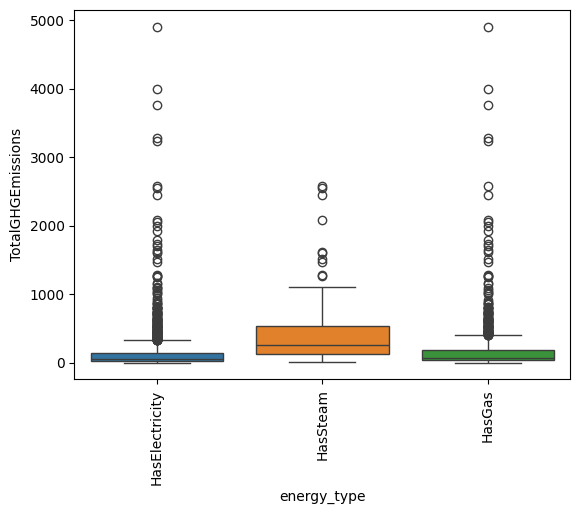

In [309]:
energy_cols = ['HasElectricity','HasSteam','HasGas']
        
df_HasEnergy = NR_building_WO_outliers_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='energy_type',
                                                      value_vars=energy_cols)
df_HasEnergy = df_HasEnergy[df_HasEnergy['Presence']==True]
sns.boxplot(data=df_HasEnergy, x='energy_type', y='TotalGHGEmissions', hue='energy_type')
plt.xticks(rotation=90)

**Conclusion :** On constate que les batiements aillant de la vapeur produisent plus de CO²

### PLOT : Energie star score en fonction du type d'energie

([0, 1, 2],
 [Text(0, 0, 'HasElectricity'), Text(1, 0, 'HasSteam'), Text(2, 0, 'HasGas')])

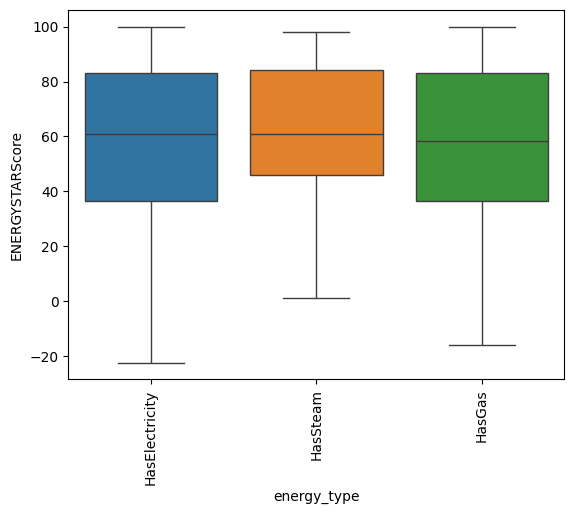

In [310]:
df_HasEnergy = NR_building_WO_outliers_consumption.melt(id_vars='ENERGYSTARScore',
                                                      value_name='Presence',
                                                      var_name='energy_type',
                                                      value_vars=energy_cols)
df_HasEnergy = df_HasEnergy[df_HasEnergy['Presence']==True]
sns.boxplot(data=df_HasEnergy, x='energy_type', y='ENERGYSTARScore', hue='energy_type')
plt.xticks(rotation=90)

### PLOT : Emissions en fonction du quartier

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Neighborhood_BALLARD'),
  Text(1, 0, 'Neighborhood_CENTRAL'),
  Text(2, 0, 'Neighborhood_DELRIDGE'),
  Text(3, 0, 'Neighborhood_DOWNTOWN'),
  Text(4, 0, 'Neighborhood_EAST'),
  Text(5, 0, 'Neighborhood_GREATER DUWAMISH'),
  Text(6, 0, 'Neighborhood_LAKE UNION'),
  Text(7, 0, 'Neighborhood_MAGNOLIA / QUEEN ANNE'),
  Text(8, 0, 'Neighborhood_NORTH'),
  Text(9, 0, 'Neighborhood_NORTHEAST'),
  Text(10, 0, 'Neighborhood_NORTHWEST'),
  Text(11, 0, 'Neighborhood_SOUTHEAST'),
  Text(12, 0, 'Neighborhood_SOUTHWEST')])

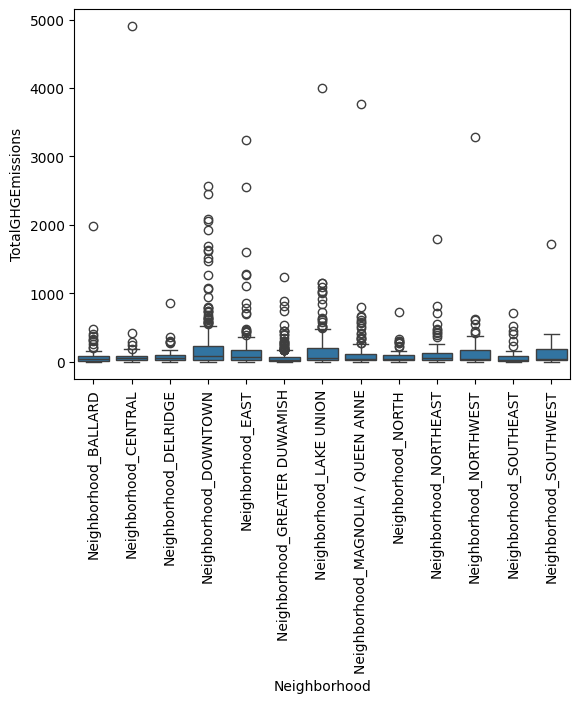

In [311]:
Neighborhood_cols = []
for col in NR_building_WO_outliers_consumption.columns:
    if col.startswith('Neighborhood'):
        Neighborhood_cols.append(col)
        
df_Neighborhood = NR_building_WO_outliers_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='Neighborhood',
                                                      value_vars=Neighborhood_cols)
df_Neighborhood = df_Neighborhood[df_Neighborhood['Presence']==True]
sns.boxplot(data=df_Neighborhood, x='Neighborhood', y='TotalGHGEmissions')
plt.xticks(rotation=90)

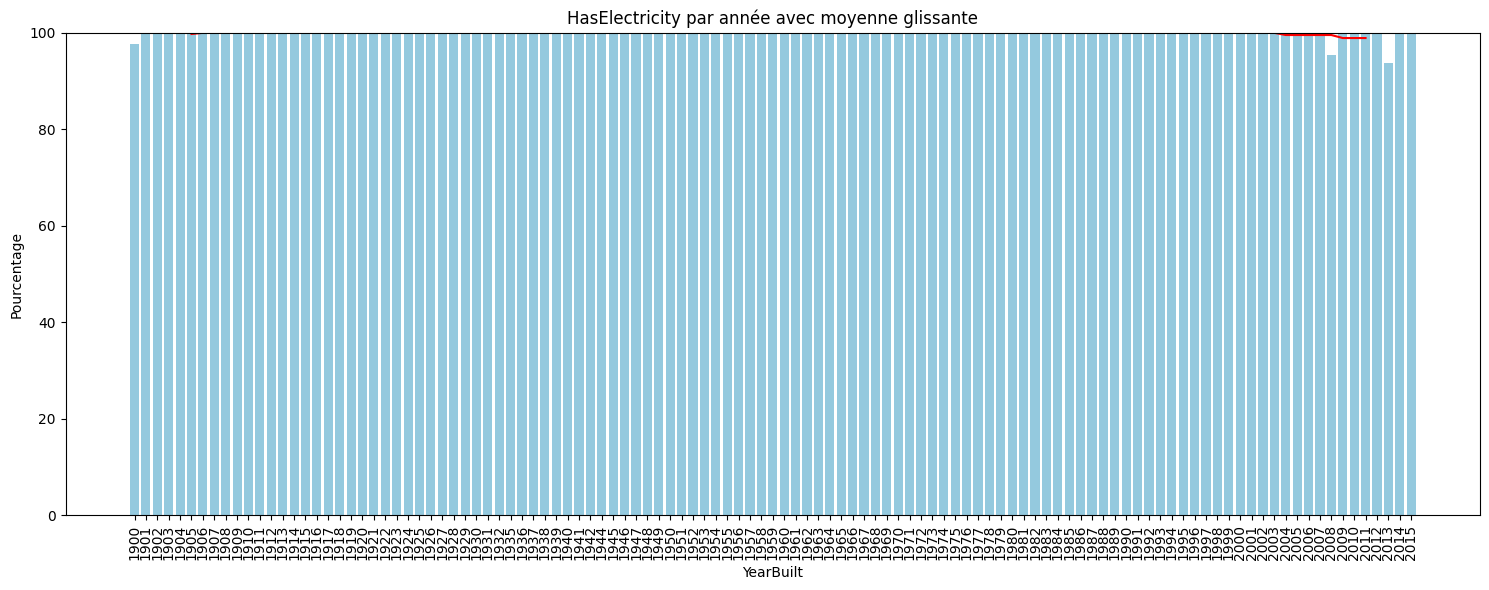

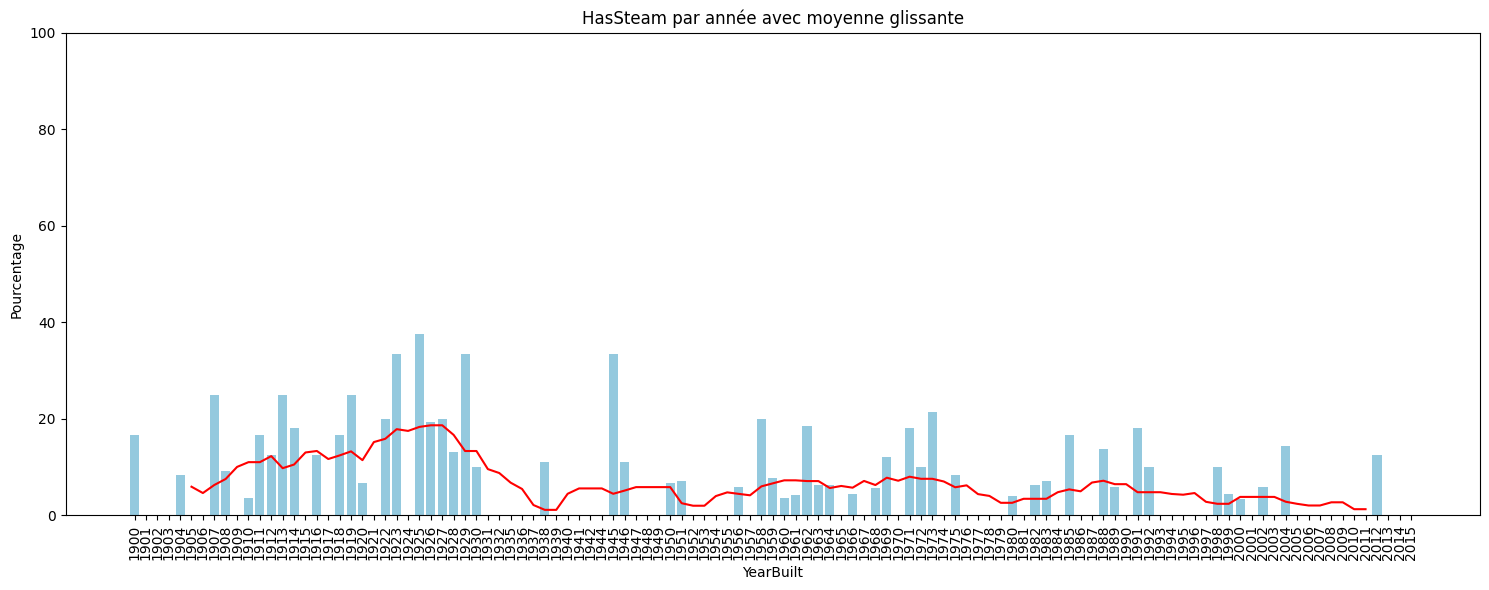

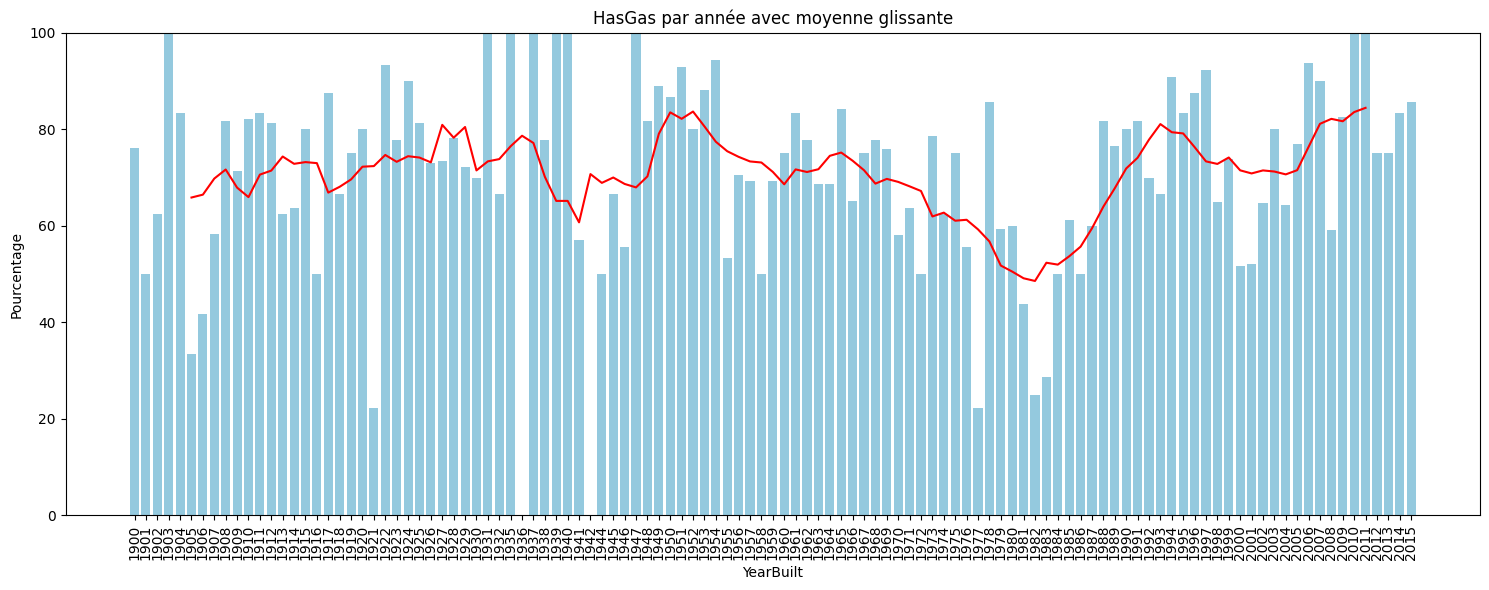

In [312]:
energies = ['HasElectricity','HasSteam','HasGas']

Energy_per_year = NR_building_WO_outliers_consumption[['YearBuilt','HasElectricity','HasSteam','HasGas']]
total_bat = Energy_per_year.groupby('YearBuilt').size().reset_index(name='Total')
Energy_per_year = Energy_per_year.groupby('YearBuilt').sum().reset_index()
Energy_per_year_percentage = Energy_per_year.merge(total_bat,on='YearBuilt')
Energy_per_year_percentage[energies] = Energy_per_year_percentage[energies].apply(lambda x : x / Energy_per_year_percentage['Total']*100)
for energy in energies:
    Energy_per_year_percentage[f'10Years_rolling_{energy}'] = Energy_per_year_percentage[energy].rolling(window=10, center=True).mean()

    Energy_per_year_percentage['YearBuilt'] = Energy_per_year_percentage['YearBuilt'].astype(str)



    fig, ax = plt.subplots(figsize=(15, 6))

    # Barplot
    sns.barplot(data=Energy_per_year_percentage, x='YearBuilt', y=energy, ax=ax, color='skyblue')

    # Lineplot
    sns.lineplot(data=Energy_per_year_percentage, x='YearBuilt', y=f'10Years_rolling_{energy}', ax=ax, color='red')

    # Contraindre les limites de l'axe Y
    ax.set_ylim(0, 100)  # Par exemple, si tu veux afficher des pourcentages

    # Améliorer la lisibilité
    ax.set_ylabel('Pourcentage')
    plt.title(f"{energy} par année avec moyenne glissante")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()




**Conclusion :**  
On constate 3 choses :
 - Pratiquement tous les batiments ont de l'electricité
 - Très peu de batiment ont de la vapeur
 - La répartition de présence de gaz est différente selon le type de batiment

On sait aussi que dépendement de l'année de construction, les batiments ont plus ou moins accès à la vapeur et au gaz

# EMISSIONS CO²

## Séparation du jeu de donnée en X et y

In [313]:
y = NR_building_WO_outliers_consumption['TotalGHGEmissions']
X = NR_building_WO_outliers_consumption.drop('TotalGHGEmissions', axis=1)

In [314]:
y.head()

0     249.98
1     295.86
2    2089.28
3     286.43
4     505.01
Name: TotalGHGEmissions, dtype: float64

In [315]:
X.head()


,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,...,Neighborhood_DOWNTOWN,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
0,47.61220,-122.33799,1927,1.0,12,88434,0,88434,12,88434.0,...,True,False,False,False,False,False,False,False,False,False
1,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,12,83880.0,...,True,False,False,False,False,False,False,False,False,False
2,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,12,756493.0,...,True,False,False,False,False,False,False,False,False,False
3,47.61412,-122.33664,1926,1.0,10,61320,0,61320,12,61320.0,...,True,False,False,False,False,False,False,False,False,False
4,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,12,123445.0,...,True,False,False,False,False,False,False,False,False,False


## Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

## Séparation jeu apprentissage et test

In [316]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## DummyRegressor


In [317]:
# Dummy model est un model 'bete' de référence. il servira a constater de la performance ou non des autres modèles
dummy_model = DummyRegressor(strategy='mean')
Score_Dummy = cross_validate(dummy_model,X_train, y_train, cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
Dummy_results = pd.DataFrame(Score_Dummy)
Dummy_results


,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.006563,0.004012,-0.000063,-139250.417920,-158.633058
1,0.003155,0.000000,-0.000700,-94870.666263,-157.776137
2,0.000000,0.008547,-0.000544,-76756.768958,-154.824613
3,0.000000,0.000000,-0.002585,-167726.916240,-174.978329
4,0.007857,0.000000,-0.000135,-74791.252896,-153.038831


In [318]:
df_dummy = pd.DataFrame([Dummy_results.mean()])
df_dummy

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.003515,0.002512,-0.000805,-110679.204455,-159.850194


In [319]:
dummy_model.fit(X_train,y_train)
y_dummy_pred = dummy_model.predict(X_test)

In [320]:
print(r2_score(y_test,y_dummy_pred))
print(mean_squared_error(y_test,y_dummy_pred))
print(mean_absolute_error(y_test,y_dummy_pred))

-0.003377852827860517
105037.8049821038
159.03989209434582


## LinearRegression

In [321]:
STDScaler = StandardScaler()
X_train_normalized = X_train.copy()
X_test_normalized = X_test.copy()

columns_to_standardize = ['LargestPropertyUseTypeGFA','SecondLargestPropertyUseTypeGFA','ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore']
for column in columns_to_standardize:
    X_train_normalized[column] = STDScaler.fit_transform(X_train_normalized[[column]])
    X_test_normalized[column] = STDScaler.transform(X_test_normalized[[column]])



In [322]:
X_train_normalized.describe()

,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,ElecRatio,SteamRatio,NaturalGasRatio
count,1228.000000,1228.000000,1228.000000,1228.000000,1228.000000,1.228000e+03,1228.000000,1.228000e+03,1228.000000,1.228000e+03,1228.000000,1.228000e+03,1228.000000,1.228000e+03,1.228000e+03,1.228000e+03,1228.000000,1228.000000
mean,47.616447,-122.333869,1961.793160,1.142508,4.246743,1.108055e+05,14555.698697,9.624984e+04,26.526059,2.893089e-18,36.282573,4.050325e-17,34.625407,1.446545e-17,2.719504e-16,7.291685e+04,2884.002401,20672.648494
std,0.046313,0.023423,32.903225,1.256138,6.044000,1.727153e+05,44717.325281,1.468478e+05,12.866760,1.000407e+00,11.370652,1.000407e+00,8.928845,1.000407e+00,1.000407e+00,1.269077e+05,15374.808700,37850.596152
min,47.509590,-122.411820,1900.000000,1.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,0.000000,-6.450434e-01,0.000000,-4.219525e-01,0.000000,-2.343847e-01,-2.911600e+00,0.000000e+00,0.000000,0.000000
25%,47.589010,-122.343250,1929.750000,1.000000,1.000000,2.937000e+04,0.000000,2.825800e+04,22.000000,-4.622856e-01,31.000000,-4.219525e-01,39.000000,-2.343847e-01,-7.898367e-01,1.871062e+04,0.000000,0.000000
50%,47.613150,-122.333015,1966.000000,1.000000,2.000000,4.822950e+04,0.000000,4.629250e+04,23.000000,-3.343341e-01,39.000000,-3.876919e-01,39.000000,-2.343847e-01,5.465478e-02,3.135828e+04,0.000000,11103.277782
75%,47.648657,-122.323018,1989.000000,1.000000,5.000000,1.079565e+05,0.000000,9.638250e+04,30.000000,2.341568e-02,47.000000,-8.807324e-02,39.000000,-2.343847e-01,8.799267e-01,7.061312e+04,0.000000,24148.056663
max,47.733870,-122.261800,2015.000000,27.000000,55.000000,1.585960e+06,512608.000000,1.380959e+06,55.000000,1.087372e+01,47.000000,8.276916e+00,39.000000,1.664557e+01,1.491319e+00,1.374453e+06,224651.604167,400651.380330


In [323]:
Linear_regression_model = LinearRegression()
Score_Linear_regression = cross_validate(Linear_regression_model,X_train_normalized, y_train, cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_Linear_regression = pd.DataFrame(Score_Linear_regression)
results_Linear_regression

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.043559,0.014178,0.618891,-53066.314580,-97.174601
1,0.018342,0.014325,0.676407,-30678.004224,-99.151903
2,0.016257,0.008102,0.696656,-23271.067266,-90.475029
3,0.012569,0.008122,0.702367,-49792.319574,-99.644484
4,0.016538,0.008061,0.516778,-36135.868613,-93.834838


In [324]:
df_Linear_regression = pd.DataFrame([results_Linear_regression.mean()])
df_Linear_regression

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.021453,0.010558,0.64222,-38588.714852,-96.056171


In [325]:
Linear_regression_model.fit(X_train_normalized,y_train)
y_LR_pred = Linear_regression_model.predict(X_test_normalized)

In [326]:
print(r2_score(y_test,y_LR_pred))
print(mean_squared_error(y_test,y_LR_pred))
print(mean_absolute_error(y_test,y_LR_pred))

0.6319317157870701
38530.93283681235
92.70692188989385


## SVR

In [327]:
SVR_model = SVR()
Score_SVR = cross_validate(SVR_model,X_train_normalized,y_train,cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_SVR = pd.DataFrame(Score_SVR)
results_SVR

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.182780,0.090843,0.010051,-137842.165113,-113.492776
1,0.166335,0.078716,0.022979,-92625.829213,-112.309334
2,0.106773,0.039965,0.013471,-75681.580677,-110.541127
3,0.082260,0.032866,-0.002526,-167716.937497,-133.550658
4,0.074285,0.041260,-0.002614,-74976.630940,-113.284401


In [328]:
df_SVR = pd.DataFrame([results_SVR.mean()])
df_SVR

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.122487,0.05673,0.008272,-109768.628688,-116.635659


In [329]:
SVR_model.fit(X_train_normalized,y_train)
y_SVR_pred = SVR_model.predict(X_test_normalized)

In [330]:
print(r2_score(y_test,y_SVR_pred))
print(mean_squared_error(y_test,y_SVR_pred))
print(mean_absolute_error(y_test,y_SVR_pred))

0.05345114201591328
99088.70728086783
101.93700386848772


## RandomForestRegressor

In [331]:
Random_forest_model = RandomForestRegressor(random_state=42)
Score_Random_forest = cross_validate(Random_forest_model, X_train,y_train,cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_Random_forest = pd.DataFrame(Score_Random_forest)
results_Random_forest

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,3.047031,0.027003,0.697956,-42057.085552,-64.501196
1,3.196724,0.033341,0.738893,-24754.066235,-64.511077
2,2.987793,0.024590,0.823075,-13572.768376,-56.425836
3,3.275753,0.065695,0.692036,-51520.637829,-76.925842
4,4.146081,0.029488,0.498054,-37536.140424,-64.075137


In [332]:
df_Random_forest = pd.DataFrame([results_Random_forest.mean()])
df_Random_forest

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,3.330677,0.036023,0.690003,-33888.139683,-65.287818


In [333]:
Random_forest_model.fit(X_train,y_train)
y_RF_pred = Random_forest_model.predict(X_test)

In [334]:
print(r2_score(y_test,y_RF_pred))
print(mean_squared_error(y_test,y_RF_pred))
print(mean_absolute_error(y_test,y_RF_pred))

0.7096001930507612
30400.270648995305
57.84481042345277


## RIDGE

In [335]:
ridge_model = Ridge(random_state=42)
score_Ridge = cross_validate(ridge_model, X_train_normalized,y_train,cv=5,scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_ridge = pd.DataFrame(score_Ridge).mean()
results_ridge


fit_time                            0.004504
score_time                          0.005290
test_r2                             0.645734
test_neg_mean_squared_error    -38271.923094
test_neg_mean_absolute_error      -95.071233
dtype: float64

## Comparaison totale

In [336]:
name = ['RandomForestRegressor','SVR','LinearRegression',"dummy"]
score_total = pd.concat([df_Random_forest,df_SVR,df_Linear_regression,df_dummy])
score_total['nom'] = name
score_total

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error,nom
0,3.330677,0.036023,0.690003,-33888.139683,-65.287818,RandomForestRegressor
0,0.122487,0.056730,0.008272,-109768.628688,-116.635659,SVR
0,0.021453,0.010558,0.642220,-38588.714852,-96.056171,LinearRegression
0,0.003515,0.002512,-0.000805,-110679.204455,-159.850194,dummy


**Conclusion :** Le model SVR n'est pas satisfaisant comparé à la RF et LR. LR à les meilleurs performances.

## Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

## RANDOM FOREST

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'NaturalGasRatio'),
  Text(1, 0, 'SteamRatio'),
  Text(2, 0, 'ENERGYSTARScore'),
  Text(3, 0, 'PropertyGFABuilding(s)'),
  Text(4, 0, 'PropertyGFATotal'),
  Text(5, 0, 'LargestPropertyUseType'),
  Text(6, 0, 'ElecRatio'),
  Text(7, 0, 'LargestPropertyUseTypeGFA')])

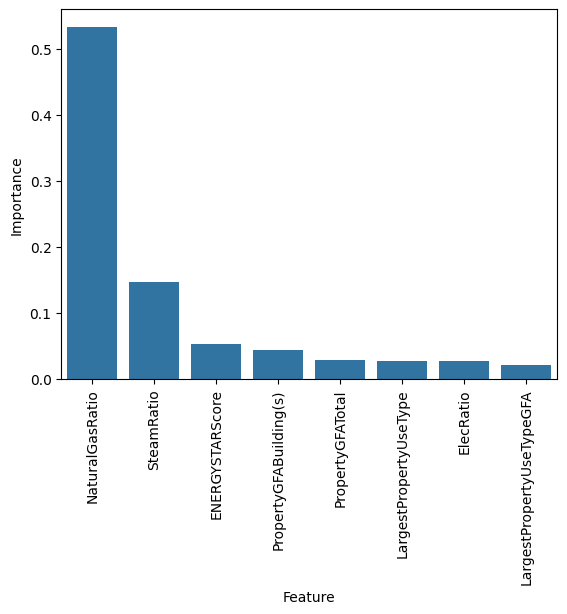

In [346]:
RF_importance = Random_forest_model.feature_importances_
feature_names = X_train.columns

df_RF_importances = pd.DataFrame({'Feature' : feature_names,'Importance':RF_importance}).sort_values(by='Importance', ascending=False)
sns.barplot(data=df_RF_importances.loc[:9,:], x='Feature', y='Importance')
plt.xticks(rotation=90)


In [347]:
params = {
    'n_estimators': [10,15,25],
    'max_depth': [None,5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [4,5,6],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True]
}
RF_grid_search = GridSearchCV(estimator=Random_forest_model,param_grid=params,cv=5,scoring='r2',n_jobs=-1,verbose=1)
RF_grid_search.fit(X_train,y_train)

# {'bootstrap': True, 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2', 0.5],
                         'min_samples_leaf': [4, 5, 6],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 15, 25]},
             scoring='r2', verbose=1)

In [348]:
# best_param_random_forest = RF_grid_search.best_params_
best_param_random_forest = {'bootstrap': True, 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}
print(best_param_random_forest)

{'bootstrap': True, 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}


In [349]:
final_random_forest_reg = RandomForestRegressor(**best_param_random_forest,random_state=42)
print(final_random_forest_reg.get_params())
final_random_forest_reg.fit(X_train,y_train)
y_final_pred = final_random_forest_reg.predict(X_test)

print(mean_absolute_error(y_test,y_final_pred))
print(mean_squared_error(y_test,y_final_pred))
print(r2_score(y_test,y_final_pred))

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 25, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
62.739080900469546
30506.791974601278
0.7085826438075615


## ridge REGRESSION

In [350]:
ridge_model.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': 42,
 'solver': 'auto',
 'tol': 0.0001}

In [351]:
R_params = {
    'alpha': [0.01,0.02,0.05,0.1,0.5,0.8,1],
    'copy_X': [True,False],
    'max_iter': [1,5,10,15,20,None],
    'fit_intercept': [True,False],
    'positive': [False]
}
LR_gridsearch = GridSearchCV(ridge_model,cv=5, param_grid=R_params,scoring = 'r2',error_score='raise')
LR_gridsearch.fit(X_train,y_train)
NN_params = LR_gridsearch.best_params_
NN_score = LR_gridsearch.best_score_
LR_gridsearch.fit(X_train_normalized,y_train)
Normalized_params = LR_gridsearch.best_params_
Normalized_score = LR_gridsearch.best_score_
print(NN_params)
print(NN_score)
print(Normalized_params)
print(Normalized_score)

c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=8.03939e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.28305e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=8.80832e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.01576e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Fab

{'alpha': 1, 'copy_X': True, 'fit_intercept': False, 'max_iter': 1, 'positive': False}
0.6449947847852695
{'alpha': 1, 'copy_X': True, 'fit_intercept': False, 'max_iter': 1, 'positive': False}
0.6457698880628474


### Gradient boosting

In [352]:
Gradient_model = GradientBoostingRegressor(random_state=42)
GSCV_params = {

    'learning_rate': [0.05,0.1,0.3],
    'max_depth': [4,5],
    'min_samples_leaf': [2,3,4],
    'min_samples_split': [2,3,4],
    'n_estimators': [100,150,200],
    'subsample': [0.6,1,2]

}
Gb_grid_search_cv = GridSearchCV(estimator=Gradient_model,param_grid=GSCV_params,cv=5,n_jobs=-1,scoring = 'r2',verbose=1)
Gb_grid_search_cv.fit(X_train,y_train)
# params = {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1}
# Gradient_model = GradientBoostingRegressor(**params_GB,random_state=42)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
810 fits failed out of a total of 2430.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
810 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parame

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.3], 'max_depth': [4, 5],
                         'min_samples_leaf': [2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [100, 150, 200],
                         'subsample': [0.6, 1, 2]},
             scoring='r2', verbose=1)

In [353]:
best_gb_params = Gb_grid_search_cv.best_params_
print(best_gb_params)

{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1}


In [354]:
Gradient_model.fit(X_train,y_train)
y_pred = Gradient_model.predict(X_test)
print(mean_absolute_error(y_pred=y_pred,y_true=y_test))
print(mean_squared_error(y_pred=y_pred,y_true=y_test))
print(r2_score(y_pred=y_pred,y_true=y_test))

59.260443903784044
28111.018250431865
0.7314683685771155


<Axes: xlabel='TotalGHGEmissions'>

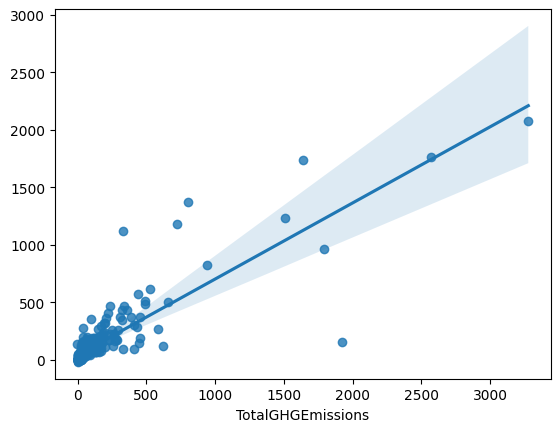

In [357]:
sns.regplot(x=y_test, y=y_pred,)